# Comprehensive Hyperparameter Tuning — Single-Pulse Autoencoders

This notebook performs an extensive random search comparing **two autoencoder architectures** on single waveforms:

1. **Dense (fully-connected) autoencoder** — flat layers, no spatial structure
2. **1D Convolutional autoencoder** — exploits the temporal structure of pulses

Both must do two things: reconstruct the waveform and provide a latent feature vector that linearly separates gammas from neutrons via a downstream logistic regression.

## Hyperparameters explored

**Shared (both architectures):**
- `model_type` — `"dense"` or `"cnn"`
- `latent_dim` — bottleneck size
- `activation`, `output_activation`
- `dropout`, `l2_reg`, `batch_norm`, `noise_std`
- `optimizer`, `learning_rate`, `batch_size`, `loss`

**Dense-only:**
- `n_layers` — encoder depth
- `start_width` — first encoder layer width
- `width_strategy` — `geometric`, `linear`, or `funnel`

**CNN-only:**
- `n_conv_layers` — number of stride-2 Conv1D layers (each halves the time axis)
- `kernel_size` — convolution kernel width (3, 5, or 7)
- `n_filters_start` — channel count of the first conv layer
- `filter_strategy` — `double` (16→32→64) or `constant`

## Per-trial evaluation

For every configuration we record:
1. `best_val_loss` — validation reconstruction loss
2. `clf_accuracy` — accuracy of a logistic regression on the encoder's latent features
3. `photon_err_pct` / `neutron_err_pct` — per-class error rates
4. `composite_score` — combined ranking metric (lower is better)

Hyperparameters that don't apply to a given architecture are stored as `None` in the results CSV, so the analysis code filters by `model_type` before reporting per-hyperparameter effects.

In [1]:
import itertools
import random
import time

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775830811.529869  758685 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775830812.178707  758685 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load and split data

Same pipeline as the baseline autoencoder notebook: load Euclidean-normalized
waveforms, split 60/20/20 train/val/test, then min-max normalize to [0, 1]
(matching the sigmoid output activation).

In [2]:
d = np.load("processed_waveforms.npz")
X = d["X_euclidean"].astype(np.float32)
y = d["y"].astype(np.int32)  # 0=photon, 1=neutron

# 60/20/20 train/val/test split
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv
)

# Min-max normalize using train set only
minv = X_train.min(axis=0, keepdims=True)
maxv = X_train.max(axis=0, keepdims=True)
den = np.maximum(maxv - minv, 1e-8)

X_train_n = (X_train - minv) / den
X_val_n   = (X_val   - minv) / den
X_test_n  = (X_test  - minv) / den

print(f"Train: {X_train_n.shape}  Val: {X_val_n.shape}  Test: {X_test_n.shape}")
print(f"Train labels: photon={(y_train==0).sum():,}  neutron={(y_train==1).sum():,}")

Train: (312006, 104)  Val: (104002, 104)  Test: (104002, 104)
Train labels: photon=152,266  neutron=159,740


## Search space definition

We use **random search** rather than grid search — the full grid is over
100,000 combinations and grid would be wasteful when most hyperparameters
interact only weakly. Random search is the standard approach for high
dimensional spaces (Bergstra & Bengio 2012).

In [3]:
# ── Search space (organized by which architecture each field applies to) ──

SHARED_SPACE = {
    "latent_dim":        [2, 4, 8, 16, 32],
    "activation":        ["relu", "elu", "leaky_relu", "swish"],
    "output_activation": ["sigmoid", "linear"],
    "dropout":           [0.0, 0.1, 0.2, 0.3],
    "l2_reg":            [0.0, 1e-5, 1e-4, 1e-3],
    "batch_norm":        [False, True],
    "noise_std":         [0.0, 0.02, 0.05, 0.1],
    "optimizer":         ["adam", "adamw", "nadam"],
    "learning_rate":     [1e-4, 3e-4, 1e-3, 3e-3],
    "batch_size":        [256, 512, 1024],
    "loss":              ["mae", "mse", "huber"],
}

DENSE_SPACE = {
    "n_layers":       [1, 2, 3, 4, 5],
    "start_width":    [32, 64, 128, 256],
    "width_strategy": ["geometric", "linear", "funnel"],
}

CNN_SPACE = {
    "n_conv_layers":   [2, 3],
    "kernel_size":     [3, 5, 7],
    "n_filters_start": [16, 32, 64],
    "filter_strategy": ["double", "constant"],
}

MODEL_TYPES = ["dense", "cnn"]

N_TRIALS   = 100   # split roughly evenly between dense and cnn
MAX_EPOCHS = 25
PATIENCE   = 6

# How many unique configs are possible?
shared_combos = 1
for v in SHARED_SPACE.values():
    shared_combos *= len(v)
dense_combos = shared_combos
for v in DENSE_SPACE.values():
    dense_combos *= len(v)
cnn_combos = shared_combos
for v in CNN_SPACE.values():
    cnn_combos *= len(v)

print(f"Dense combos: {dense_combos:,}")
print(f"CNN combos:   {cnn_combos:,}")
print(f"Total:        {dense_combos + cnn_combos:,}")
print(f"Sampling {N_TRIALS} trials")

Dense combos: 33,177,600
CNN combos:   19,906,560
Total:        53,084,160
Sampling 100 trials


## Flexible model builder

Builds an autoencoder according to a hyperparameter dictionary. Supports all
the architecture/regularization options in the search space.

**Width computation:**
- `geometric` — halve the width at each layer (`start_width`, `start_width/2`, ...)
- `linear`    — evenly spaced from `start_width` down to `latent_dim`
- `funnel`    — random monotonically decreasing widths from a base set

In [4]:
BASE_FUNNEL_WIDTHS = [256, 128, 64, 32, 16, 8]


# ── Helper functions (shared between dense and CNN) ─────────────────────────

def compute_widths(n_layers, start_width, latent_dim, strategy, rng):
    if strategy == "geometric":
        widths = []
        w = start_width
        for _ in range(n_layers):
            if w <= latent_dim:
                w = latent_dim * 2
            widths.append(int(w))
            w = max(latent_dim, w // 2)
        return widths
    elif strategy == "linear":
        end = max(latent_dim * 2, latent_dim + 4)
        if n_layers == 1:
            return [start_width]
        return np.linspace(start_width, end, n_layers).round().astype(int).tolist()
    elif strategy == "funnel":
        candidates = [w for w in BASE_FUNNEL_WIDTHS if w >= latent_dim]
        if not candidates:
            return [latent_dim * 2] * n_layers
        widths = []
        allowed = candidates.copy()
        for _ in range(n_layers):
            w = rng.choice(allowed)
            widths.append(int(w))
            allowed = [x for x in candidates if x <= w]
            if not allowed:
                allowed = [latent_dim * 2]
        return widths
    raise ValueError(f"Unknown strategy: {strategy}")


def get_activation(name):
    if name == "leaky_relu":
        return layers.LeakyReLU(negative_slope=0.1)
    return layers.Activation(name)


def get_optimizer(name, learning_rate):
    if name == "adam":  return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adamw": return keras.optimizers.AdamW(learning_rate=learning_rate)
    if name == "nadam": return keras.optimizers.Nadam(learning_rate=learning_rate)
    raise ValueError(f"Unknown optimizer: {name}")


def get_loss(name):
    if name == "mae":   return "mae"
    if name == "mse":   return "mse"
    if name == "huber": return keras.losses.Huber()
    raise ValueError(f"Unknown loss: {name}")


# ── Dense autoencoder builder ───────────────────────────────────────────────

def build_dense_autoencoder(hp, n_features, rng):
    widths = compute_widths(
        hp["n_layers"], hp["start_width"], hp["latent_dim"], hp["width_strategy"], rng
    )
    reg = regularizers.l2(hp["l2_reg"]) if hp["l2_reg"] > 0 else None

    enc_inputs = layers.Input(shape=(n_features,), name="encoder_input")
    x = enc_inputs
    if hp["noise_std"] > 0:
        x = layers.GaussianNoise(hp["noise_std"])(x)
    for w in widths:
        x = layers.Dense(w, kernel_regularizer=reg)(x)
        if hp["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = get_activation(hp["activation"])(x)
        if hp["dropout"] > 0:
            x = layers.Dropout(hp["dropout"])(x)
    latent = layers.Dense(hp["latent_dim"], name="latent")(x)
    latent = get_activation(hp["activation"])(latent)
    encoder = Model(enc_inputs, latent, name="encoder")

    dec_inputs = layers.Input(shape=(hp["latent_dim"],), name="decoder_input")
    x = dec_inputs
    for w in reversed(widths):
        x = layers.Dense(w, kernel_regularizer=reg)(x)
        if hp["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = get_activation(hp["activation"])(x)
        if hp["dropout"] > 0:
            x = layers.Dropout(hp["dropout"])(x)
    out = layers.Dense(n_features)(x)
    out = layers.Activation(hp["output_activation"])(out)
    decoder = Model(dec_inputs, out, name="decoder")

    ae_inputs = layers.Input(shape=(n_features,))
    autoencoder = Model(ae_inputs, decoder(encoder(ae_inputs)), name="autoencoder")
    autoencoder.compile(
        optimizer=get_optimizer(hp["optimizer"], hp["learning_rate"]),
        loss=get_loss(hp["loss"]),
    )
    return autoencoder, encoder, {"widths": widths}


# ── 1D Convolutional autoencoder builder ────────────────────────────────────

def build_cnn_autoencoder(hp, n_features, rng):
    n_conv = hp["n_conv_layers"]
    k = hp["kernel_size"]
    f0 = hp["n_filters_start"]
    if hp["filter_strategy"] == "double":
        filters = [f0 * (2 ** i) for i in range(n_conv)]
    else:  # constant
        filters = [f0] * n_conv

    reg = regularizers.l2(hp["l2_reg"]) if hp["l2_reg"] > 0 else None

    # ── Encoder ──
    enc_inputs = layers.Input(shape=(n_features,), name="encoder_input")
    x = layers.Reshape((n_features, 1))(enc_inputs)
    if hp["noise_std"] > 0:
        x = layers.GaussianNoise(hp["noise_std"])(x)

    spatial = n_features
    for f in filters:
        x = layers.Conv1D(f, k, strides=2, padding="same", kernel_regularizer=reg)(x)
        if hp["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = get_activation(hp["activation"])(x)
        if hp["dropout"] > 0:
            x = layers.Dropout(hp["dropout"])(x)
        spatial = (spatial + 1) // 2  # ceil(spatial / 2) for stride 2 + same padding

    flat_size = spatial * filters[-1]
    x = layers.Flatten()(x)
    latent = layers.Dense(hp["latent_dim"], name="latent")(x)
    latent = get_activation(hp["activation"])(latent)
    encoder = Model(enc_inputs, latent, name="encoder")

    # ── Decoder (mirror) ──
    dec_inputs = layers.Input(shape=(hp["latent_dim"],), name="decoder_input")
    x = layers.Dense(flat_size)(dec_inputs)
    x = get_activation(hp["activation"])(x)
    x = layers.Reshape((spatial, filters[-1]))(x)

    # All but the last filter -- transposed convs that double the spatial dim
    for f in reversed(filters[:-1]):
        x = layers.Conv1DTranspose(f, k, strides=2, padding="same", kernel_regularizer=reg)(x)
        if hp["batch_norm"]:
            x = layers.BatchNormalization()(x)
        x = get_activation(hp["activation"])(x)
        if hp["dropout"] > 0:
            x = layers.Dropout(hp["dropout"])(x)

    # Final upsample back to (n_features, 1)
    x = layers.Conv1DTranspose(1, k, strides=2, padding="same", kernel_regularizer=reg)(x)
    x = layers.Activation(hp["output_activation"])(x)
    # The output may have an extra sample if n_features wasn't a power-of-2 multiple --
    # crop or pad to exactly n_features.
    out = layers.Lambda(lambda t: t[:, :n_features, 0], output_shape=(n_features,))(x)

    decoder = Model(dec_inputs, out, name="decoder")

    ae_inputs = layers.Input(shape=(n_features,))
    autoencoder = Model(ae_inputs, decoder(encoder(ae_inputs)), name="autoencoder")
    autoencoder.compile(
        optimizer=get_optimizer(hp["optimizer"], hp["learning_rate"]),
        loss=get_loss(hp["loss"]),
    )
    return autoencoder, encoder, {"filters": filters, "spatial": spatial}


# ── Dispatcher ──────────────────────────────────────────────────────────────

def build_model(hp, n_features=104, rng=None):
    rng = rng or random.Random(0)
    if hp["model_type"] == "dense":
        return build_dense_autoencoder(hp, n_features, rng)
    elif hp["model_type"] == "cnn":
        return build_cnn_autoencoder(hp, n_features, rng)
    raise ValueError(f"Unknown model_type: {hp['model_type']}")

## Trial evaluation function

For each trial we:
1. Train the autoencoder on the train split (with early stopping on val_loss)
2. Compute reconstruction loss on the test set
3. Extract latent features for train and test
4. Train a logistic regression on the latents
5. Evaluate classification accuracy on the test set
6. Compute a composite score combining both objectives

In [5]:
def evaluate_classifier(encoder, X_train, y_train, X_test, y_test, batch_size=2048):
    # Train logistic regression on encoder features, return accuracy & per-class err.
    Z_train = encoder.predict(X_train, batch_size=batch_size, verbose=0)
    Z_test  = encoder.predict(X_test,  batch_size=batch_size, verbose=0)

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced"),
    )
    clf.fit(Z_train, y_train)
    y_pred = clf.predict(Z_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    photon_err  = fp / (tn + fp) if (tn + fp) > 0 else 0.0
    neutron_err = fn / (tp + fn) if (tp + fn) > 0 else 0.0
    return acc, photon_err, neutron_err


def composite_score(val_loss, clf_acc, alpha=0.5):
    # Combined ranking metric (lower is better)
    return alpha * val_loss + (1 - alpha) * (1 - clf_acc)


def run_trial(hp, X_train, X_val, X_test, y_train, y_test,
              max_epochs=MAX_EPOCHS, patience=PATIENCE, rng=None):
    # Build, train, evaluate one hyperparameter configuration
    keras.backend.clear_session()

    autoencoder, encoder, arch_info = build_model(hp, n_features=X_train.shape[1], rng=rng)
    n_params = autoencoder.count_params()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience,
            restore_best_weights=True, verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", patience=3, factor=0.5, verbose=0,
        ),
    ]

    t0 = time.time()
    history = autoencoder.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=max_epochs,
        batch_size=hp["batch_size"],
        callbacks=callbacks,
        shuffle=True,
        verbose=0,
    )
    train_time = time.time() - t0

    test_loss = float(autoencoder.evaluate(X_test, X_test, batch_size=hp["batch_size"], verbose=0))
    best_val  = float(np.min(history.history["val_loss"]))
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    clf_acc, photon_err, neutron_err = evaluate_classifier(
        encoder, X_train, y_train, X_test, y_test
    )

    return {
        **hp,
        **arch_info,
        "n_params": n_params,
        "best_epoch": best_epoch,
        "best_val_loss": best_val,
        "test_loss": test_loss,
        "clf_accuracy": clf_acc,
        "photon_err_pct": photon_err * 100,
        "neutron_err_pct": neutron_err * 100,
        "composite_score": composite_score(best_val, clf_acc),
        "train_time_s": round(train_time, 1),
    }

## Run the random search

Each trial trains an autoencoder, then a logistic regression on its latents.
Results are saved incrementally to `hyperparam_singles_results.csv` so you
won't lose progress if interrupted.

In [6]:
def sample_config(rng):
    # Pick model_type and only sample hyperparameters relevant to it.
    # Architecture-irrelevant fields are set to None so the CSV is consistent.
    model_type = rng.choice(MODEL_TYPES)
    cfg = {"model_type": model_type}
    for k, v in SHARED_SPACE.items():
        cfg[k] = rng.choice(v)

    if model_type == "dense":
        for k, v in DENSE_SPACE.items():
            cfg[k] = rng.choice(v)
        for k in CNN_SPACE:
            cfg[k] = None
    else:
        for k, v in CNN_SPACE.items():
            cfg[k] = rng.choice(v)
        for k in DENSE_SPACE:
            cfg[k] = None
    return cfg


def config_to_key(cfg):
    return tuple(sorted(cfg.items()))


rng = random.Random(42)
results = []

# Sample N_TRIALS unique configs
sampled_configs = []
seen = set()
while len(sampled_configs) < N_TRIALS:
    cfg = sample_config(rng)
    key = config_to_key(cfg)
    if key not in seen:
        seen.add(key)
        sampled_configs.append(cfg)

n_dense = sum(1 for c in sampled_configs if c["model_type"] == "dense")
n_cnn = sum(1 for c in sampled_configs if c["model_type"] == "cnn")
print(f"Sampled {len(sampled_configs)} configs: {n_dense} dense, {n_cnn} cnn")

for trial_num, hp in enumerate(sampled_configs):
    print(f"\n{'='*78}")
    print(f"Trial {trial_num+1}/{len(sampled_configs)}  [{hp['model_type'].upper()}]")
    if hp["model_type"] == "dense":
        print(f"  arch:  latent={hp['latent_dim']} layers={hp['n_layers']} start={hp['start_width']} "
              f"strategy={hp['width_strategy']} act={hp['activation']} out={hp['output_activation']}")
    else:
        print(f"  arch:  latent={hp['latent_dim']} conv_layers={hp['n_conv_layers']} kernel={hp['kernel_size']} "
              f"f0={hp['n_filters_start']} {hp['filter_strategy']} act={hp['activation']} out={hp['output_activation']}")
    print(f"  reg:   dropout={hp['dropout']} l2={hp['l2_reg']} bn={hp['batch_norm']} noise={hp['noise_std']}")
    print(f"  opt:   {hp['optimizer']} lr={hp['learning_rate']} bs={hp['batch_size']} loss={hp['loss']}")

    try:
        result = run_trial(hp, X_train_n, X_val_n, X_test_n, y_train, y_test, rng=rng)
        results.append(result)
        print(f"  -> val_loss={result['best_val_loss']:.5f}  "
              f"clf_acc={result['clf_accuracy']:.4f}  "
              f"score={result['composite_score']:.5f}  "
              f"params={result['n_params']:,}  "
              f"time={result['train_time_s']}s")
    except Exception as e:
        print(f"  -> FAILED: {e}")
        continue

    df = pd.DataFrame(results)
    df.to_csv("hyperparam_singles_results.csv", index=False)

print(f"\n{'='*78}")
print(f"Complete: {len(results)} successful trials out of {len(sampled_configs)}")

Sampled 100 configs: 55 dense, 45 cnn

Trial 1/100  [DENSE]
  arch:  latent=2 layers=1 start=64 strategy=geometric act=leaky_relu out=sigmoid
  reg:   dropout=0.1 l2=1e-05 bn=False noise=0.0
  opt:   nadam lr=0.003 bs=256 loss=mae


I0000 00:00:1775830814.058575  758685 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1278 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a
I0000 00:00:1775830815.103312  758878 service.cc:153] XLA service 0x797c08033320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775830815.103325  758878 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1775830815.128270  758878 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775830815.196411  758878 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1775830815.222902  758878 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2256__.12
I0000 00:00:1775830816.488003  758878 de

  -> val_loss=0.02991  clf_acc=0.9843  score=0.02282  params=13,802  time=28.0s

Trial 2/100  [DENSE]
  arch:  latent=32 layers=2 start=64 strategy=linear act=elu out=linear
  reg:   dropout=0.1 l2=0.001 bn=True noise=0.0
  opt:   adam lr=0.003 bs=512 loss=mse


I0000 00:00:1775830845.332536  758876 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_132561__.42
I0000 00:00:1775830847.549393  758876 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_132561__.42
I0000 00:00:1775830849.419607  758878 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775830849.419900  758878 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775830849.916755  763362 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 16 bytes spill stores,

  -> val_loss=0.00312  clf_acc=0.9866  score=0.00825  params=27,016  time=12.7s

Trial 3/100  [DENSE]
  arch:  latent=2 layers=4 start=32 strategy=funnel act=swish out=sigmoid
  reg:   dropout=0.2 l2=0.0001 bn=True noise=0.0
  opt:   nadam lr=0.003 bs=1024 loss=mae


...

  -> val_loss=0.03164  clf_acc=0.9833  score=0.02418  params=2,608  time=25.2s

Trial 99/100  [DENSE]
  arch:  latent=32 layers=2 start=256 strategy=linear act=relu out=linear
  reg:   dropout=0.0 l2=1e-05 bn=True noise=0.1
  opt:   nadam lr=0.0003 bs=512 loss=mae


I0000 00:00:1775833787.193977  758875 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7169609__.38
I0000 00:00:1775833787.356414 1150957 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_36', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1775833789.739456  758889 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7169609__.38
I0000 00:00:1775833791.866799  758889 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775833791.867238  758889 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the f

  -> val_loss=0.02861  clf_acc=0.9884  score=0.02009  params=93,448  time=22.8s

Trial 100/100  [DENSE]
  arch:  latent=16 layers=1 start=128 strategy=geometric act=relu out=linear
  reg:   dropout=0.2 l2=1e-05 bn=True noise=0.0
  opt:   adamw lr=0.0003 bs=256 loss=mse


I0000 00:00:1775833813.567959  758881 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7237780__.24
I0000 00:00:1775833815.445337  758881 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7237780__.24
I0000 00:00:1775833816.975188  758881 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775833817.224209 1155051 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 8 bytes spill stores, 16 bytes spill loads



  -> val_loss=0.00162  clf_acc=0.9887  score=0.00648  params=32,120  time=29.4s

Complete: 100 successful trials out of 100


## Results: top configurations

In [7]:
df = pd.DataFrame(results)

print(f"Trials by model type:")
print(df["model_type"].value_counts().to_string())
print()

# ── Top 10 overall by composite score ──
print("=" * 90)
print("TOP 10 OVERALL (by composite score)")
print("=" * 90)
shared_cols = ["model_type", "latent_dim", "activation", "output_activation",
               "dropout", "l2_reg", "batch_norm", "noise_std",
               "optimizer", "learning_rate", "batch_size", "loss",
               "best_val_loss", "clf_accuracy", "composite_score", "n_params"]
print(df.sort_values("composite_score").head(10)[shared_cols].to_string())

# ── Top 5 dense ──
print("\n" + "=" * 90)
print("TOP 5 DENSE")
print("=" * 90)
dense_df = df[df["model_type"] == "dense"]
if len(dense_df) > 0:
    dense_cols = shared_cols + ["n_layers", "start_width", "width_strategy"]
    print(dense_df.sort_values("composite_score").head(5)[dense_cols].to_string())

# ── Top 5 CNN ──
print("\n" + "=" * 90)
print("TOP 5 CNN")
print("=" * 90)
cnn_df = df[df["model_type"] == "cnn"]
if len(cnn_df) > 0:
    cnn_cols = shared_cols + ["n_conv_layers", "kernel_size", "n_filters_start", "filter_strategy"]
    print(cnn_df.sort_values("composite_score").head(5)[cnn_cols].to_string())

# ── Architecture summary ──
print("\n" + "=" * 90)
print("ARCHITECTURE COMPARISON (mean across all trials)")
print("=" * 90)
summary = df.groupby("model_type").agg(
    n_trials=("composite_score", "count"),
    mean_val_loss=("best_val_loss", "mean"),
    median_val_loss=("best_val_loss", "median"),
    mean_clf_acc=("clf_accuracy", "mean"),
    median_clf_acc=("clf_accuracy", "median"),
    best_composite=("composite_score", "min"),
    mean_params=("n_params", "mean"),
)
print(summary.round(5).to_string())

Trials by model type:
model_type
dense    55
cnn      45

TOP 10 OVERALL (by composite score)
   model_type  latent_dim  activation output_activation  dropout   l2_reg  batch_norm  noise_std optimizer  learning_rate  batch_size   loss  best_val_loss  clf_accuracy  composite_score  n_params
61        cnn          32        relu           sigmoid      0.1  0.00010       False       0.00     adamw         0.0001        1024  huber       0.001356      0.990914         0.005221     29841
3         cnn          32  leaky_relu           sigmoid      0.0  0.00000       False       0.05      adam         0.0003         256    mse       0.001006      0.990539         0.005233    136993
77        cnn          32  leaky_relu            linear      0.3  0.00000       False       0.02     adamw         0.0030         256    mse       0.001137      0.990202         0.005468     48033
65        cnn          32  leaky_relu            linear      0.0  0.00100        True       0.00     nadam         0.0

## Visualization: per-hyperparameter effects

These plots show how each individual hyperparameter affects classification
accuracy. Red dot = mean for that value. Use these to spot which values
consistently work and which to drop in a follow-up search.

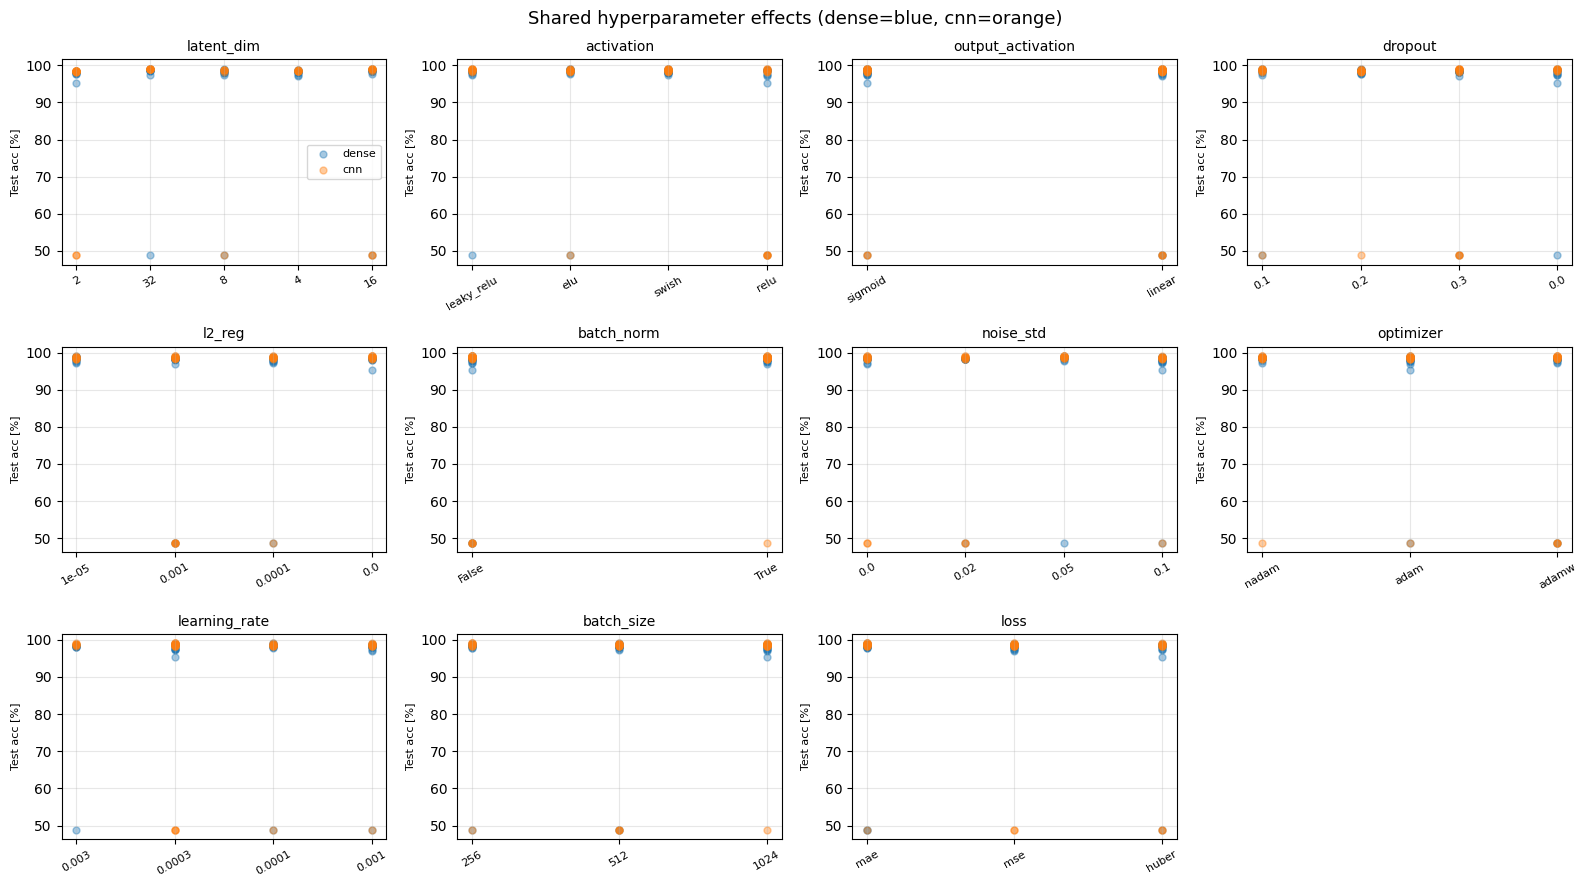

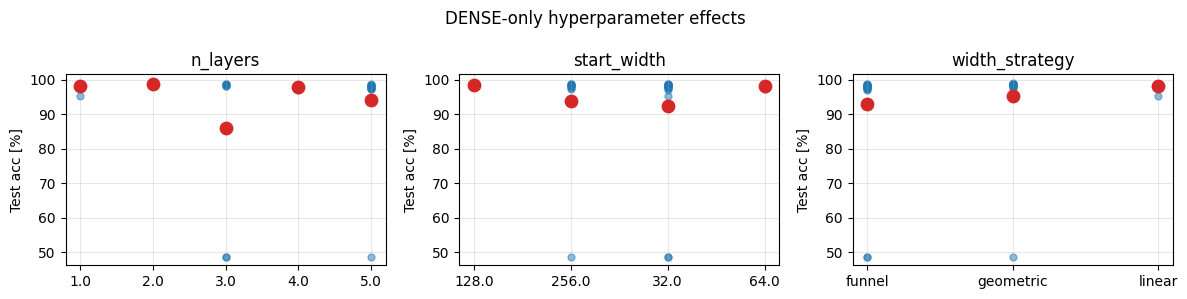

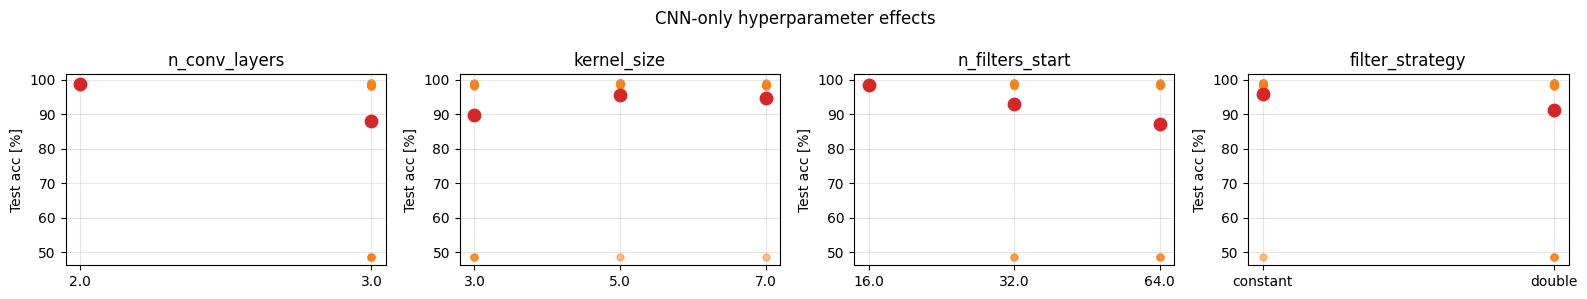

In [8]:
# ── Per-hyperparameter effect plots, colored by model type ──

shared_hps = [
    "latent_dim", "activation", "output_activation",
    "dropout", "l2_reg", "batch_norm", "noise_std",
    "optimizer", "learning_rate", "batch_size", "loss",
]

ncols = 4
nrows = int(np.ceil(len(shared_hps) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

color_map = {"dense": "tab:blue", "cnn": "tab:orange"}

for ax, hp_name in zip(axes, shared_hps):
    for mt in ["dense", "cnn"]:
        sub = df[df["model_type"] == mt]
        if len(sub) == 0:
            continue
        vals = sub[hp_name].astype(str)
        ax.scatter(vals, sub["clf_accuracy"] * 100,
                   alpha=0.4, s=25, color=color_map[mt], label=mt)
    ax.set_title(hp_name, fontsize=10)
    ax.set_ylabel("Test acc [%]", fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=8)
for j in range(len(shared_hps), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Shared hyperparameter effects (dense=blue, cnn=orange)", fontsize=13)
plt.tight_layout()
plt.show()


# ── Dense-specific hyperparameters ──
dense_df = df[df["model_type"] == "dense"]
if len(dense_df) > 0:
    dense_hps = ["n_layers", "start_width", "width_strategy"]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, hp_name in zip(axes, dense_hps):
        vals = dense_df[hp_name].astype(str)
        unique = sorted(vals.unique())
        for v in unique:
            mask = vals == v
            ax.scatter([v] * mask.sum(),
                       dense_df.loc[mask, "clf_accuracy"].values * 100,
                       alpha=0.5, s=25, color="tab:blue")
        means = dense_df.groupby(vals)["clf_accuracy"].mean() * 100
        ax.scatter(means.index, means.values, color="tab:red", s=80, zorder=5, label="Mean")
        ax.set_title(hp_name)
        ax.set_ylabel("Test acc [%]")
        ax.grid(True, alpha=0.3)
    fig.suptitle("DENSE-only hyperparameter effects", fontsize=12)
    plt.tight_layout()
    plt.show()


# ── CNN-specific hyperparameters ──
cnn_df = df[df["model_type"] == "cnn"]
if len(cnn_df) > 0:
    cnn_hps = ["n_conv_layers", "kernel_size", "n_filters_start", "filter_strategy"]
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for ax, hp_name in zip(axes, cnn_hps):
        vals = cnn_df[hp_name].astype(str)
        unique = sorted(vals.unique())
        for v in unique:
            mask = vals == v
            ax.scatter([v] * mask.sum(),
                       cnn_df.loc[mask, "clf_accuracy"].values * 100,
                       alpha=0.5, s=25, color="tab:orange")
        means = cnn_df.groupby(vals)["clf_accuracy"].mean() * 100
        ax.scatter(means.index, means.values, color="tab:red", s=80, zorder=5, label="Mean")
        ax.set_title(hp_name)
        ax.set_ylabel("Test acc [%]")
        ax.grid(True, alpha=0.3)
    fig.suptitle("CNN-only hyperparameter effects", fontsize=12)
    plt.tight_layout()
    plt.show()

## Pareto front: reconstruction vs classification

Models in the lower-right region (low reconstruction loss AND high
classification accuracy) are the best overall. Use this plot to spot the
tradeoff: pure reconstruction quality doesn't always give the best features
for classification.

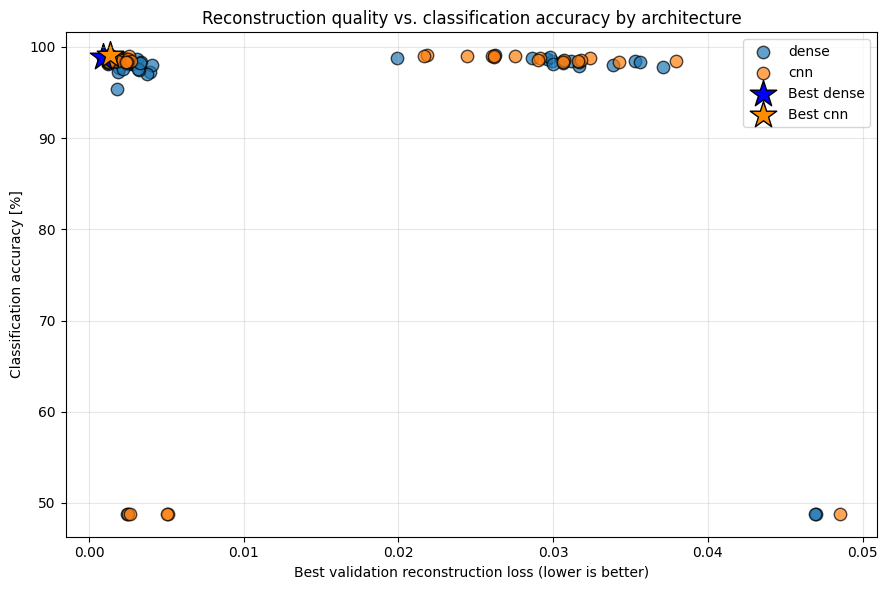

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

for mt, color in [("dense", "tab:blue"), ("cnn", "tab:orange")]:
    sub = df[df["model_type"] == mt]
    ax.scatter(sub["best_val_loss"], sub["clf_accuracy"] * 100,
               s=80, alpha=0.7, edgecolors="k", color=color, label=mt)

ax.set_xlabel("Best validation reconstruction loss (lower is better)")
ax.set_ylabel("Classification accuracy [%]")
ax.set_title("Reconstruction quality vs. classification accuracy by architecture")
ax.grid(True, alpha=0.3)
ax.legend()

# Highlight the best composite scores per model_type
for mt, color in [("dense", "blue"), ("cnn", "darkorange")]:
    sub = df[df["model_type"] == mt]
    if len(sub) == 0:
        continue
    best = sub.loc[sub["composite_score"].idxmin()]
    ax.scatter([best["best_val_loss"]], [best["clf_accuracy"] * 100],
               marker="*", s=400, color=color, edgecolors="k",
               label=f"Best {mt}")

ax.legend()
plt.tight_layout()
plt.show()

## Best configuration summary

In [10]:
def print_best(label, sub_df):
    if len(sub_df) == 0:
        print(f"\n{label}: no trials")
        return
    best = sub_df.loc[sub_df["composite_score"].idxmin()]
    print("=" * 70)
    print(f"BEST {label}")
    print("=" * 70)
    print(f"  model_type:        {best['model_type']}")
    print(f"  latent_dim:        {int(best['latent_dim'])}")
    if best["model_type"] == "dense":
        print(f"  n_layers:          {int(best['n_layers'])}")
        print(f"  start_width:       {int(best['start_width'])}")
        print(f"  width_strategy:    {best['width_strategy']}")
        if "widths" in best.index and best["widths"] is not None:
            print(f"  widths:            {best['widths']}")
    else:
        print(f"  n_conv_layers:     {int(best['n_conv_layers'])}")
        print(f"  kernel_size:       {int(best['kernel_size'])}")
        print(f"  n_filters_start:   {int(best['n_filters_start'])}")
        print(f"  filter_strategy:   {best['filter_strategy']}")
        if "filters" in best.index and best["filters"] is not None:
            print(f"  filters:           {best['filters']}")
    print(f"  activation:        {best['activation']}")
    print(f"  output_activation: {best['output_activation']}")
    print(f"  dropout:           {best['dropout']}")
    print(f"  l2_reg:            {best['l2_reg']}")
    print(f"  batch_norm:        {best['batch_norm']}")
    print(f"  noise_std:         {best['noise_std']}")
    print(f"  optimizer:         {best['optimizer']}")
    print(f"  learning_rate:     {best['learning_rate']}")
    print(f"  batch_size:        {int(best['batch_size'])}")
    print(f"  loss:              {best['loss']}")
    print()
    print(f"  n_params:          {int(best['n_params']):,}")
    print(f"  best_val_loss:     {best['best_val_loss']:.5f}")
    print(f"  test_loss:         {best['test_loss']:.5f}")
    print(f"  clf_accuracy:      {best['clf_accuracy']:.4f}")
    print(f"  photon_err_pct:    {best['photon_err_pct']:.2f}%")
    print(f"  neutron_err_pct:   {best['neutron_err_pct']:.2f}%")
    print(f"  composite_score:   {best['composite_score']:.5f}")
    print(f"  best_epoch:        {int(best['best_epoch'])}")
    print(f"  train_time_s:      {best['train_time_s']}")


print_best("OVERALL", df)
print()
print_best("DENSE", df[df["model_type"] == "dense"])
print()
print_best("CNN", df[df["model_type"] == "cnn"])

df.to_csv("hyperparam_singles_results.csv", index=False)
print("\nFull results saved to hyperparam_singles_results.csv")

BEST OVERALL
  model_type:        cnn
  latent_dim:        32
  n_conv_layers:     2
  kernel_size:       5
  n_filters_start:   16
  filter_strategy:   constant
  filters:           [16, 16]
  activation:        relu
  output_activation: sigmoid
  dropout:           0.1
  l2_reg:            0.0001
  batch_norm:        False
  noise_std:         0.0
  optimizer:         adamw
  learning_rate:     0.0001
  batch_size:        1024
  loss:              huber

  n_params:          29,841
  best_val_loss:     0.00136
  test_loss:         0.00135
  clf_accuracy:      0.9909
  photon_err_pct:    0.98%
  neutron_err_pct:   0.84%
  composite_score:   0.00522
  best_epoch:        25
  train_time_s:      17.0

BEST DENSE
  model_type:        dense
  latent_dim:        32
  n_layers:          3
  start_width:       128
  width_strategy:    linear
  widths:            [128, 96, 64]
  activation:        swish
  output_activation: sigmoid
  dropout:           0.1
  l2_reg:            0.0
  batch_norm